# University of Wyoming and UFS-Chem: Read Paired Data and Create Plots

Our first example will demonstrate the basics available in MELODIES MONET to compare the UFS-Chem model results against University of Wyoming sonde observations (https://weather.uwyo.edu/upperair/sounding.shtml) for dewpoint, relative humidity, wind speed, wind direction, potential temperature, and specific humidity.

This example reads in the University of Wyoming paired data created by the scripts here on Hera (/scratch1/BMC/rcm2/rhs/monet_example/AEROMMA/submit_jobs). This includes analysis over a day and a sampling of 2s.

First, we import the melodies_monet.driver module.

In [1]:
from melodies_monet import driver

## Analysis driver class

Now, lets create an instance of the analysis driver class, melodies_monet.driver.analysis. It consists of these main parts:

* model instances

* observation instances

* a paired instance of both

In [2]:
an = driver.analysis()

Initially, most of our analysis object’s attributes are set to None, though some have meaningful defaults:

In [3]:
an

analysis(
    control='control.yaml',
    control_dict=None,
    models={},
    obs={},
    paired={},
    start_time=None,
    end_time=None,
    time_intervals=None,
    download_maps=True,
    output_dir=None,
    output_dir_save=None,
    output_dir_read=None,
    debug=False,
    save=None,
    read=None,
    regrid=False,
)

## Control file

We set the YAML control file and begin by reading the file.

In [4]:
control_fn='control_read_looped_aircraft_UWY_UFS_CHEM.yaml'
an.control=control_fn
an.read_control() 
an.control_dict  

{'analysis': {'start_time': '2023-06-27 23:00:00',
  'end_time': '2023-06-28-23:59:00',
  'output_dir': './output/uwy_ufschem',
  'debug': True,
  'read': {'paired': {'method': 'netcdf',
    'filenames': {'uwy_ufschem': ['/home/lthompson/mm/update_boxplots/output/uwy_ufschem/0627_L1_uwy_ufschem.nc4']}}}},
 'model': {'ufschem': {'files': 'example:ufschem:2023-06',
   'mod_type': 'ufschem',
   'radius_of_influence': 100000,
   'extra_calc': {'dewpoint': {'specific_hum': 'spfh'},
    'rel_hum': {'specific_hum': 'spfh'},
    'windspeed': {'u_comp': 'ugrd', 'v_comp': 'vgrd'},
    'winddir': {'u_comp': 'ugrd', 'v_comp': 'vgrd'},
    'ptemp_mod': {'temperature': 'temperature_k',
     'u_comp': 'ugrd',
     'v_comp': 'vgrd'}},
   'mapping': {'uwy': {'temperature_k': 'temperature_C',
     'dewpoint': 'dpt_obs',
     'rel_hum': 'relh_obs',
     'windspeed': 'windspeed_obs',
     'spfh': 'w',
     'winddir': 'wdir_obs',
     'ptemp_mod': 'ptemp_obs'}},
   'variables': {'pres_pa_mid': {'rename': '

Now, some of our analysis object’s attributes are populated:

In [5]:
an

analysis(
    control='control_read_looped_aircraft_UWY_UFS_CHEM.yaml',
    control_dict=...,
    models={},
    obs={},
    paired={},
    start_time=Timestamp('2023-06-27 23:00:00'),
    end_time=Timestamp('2023-06-28 23:59:00'),
    time_intervals=None,
    download_maps=True,
    output_dir='./output/uwy_ufschem',
    output_dir_save='./output/uwy_ufschem',
    output_dir_read='./output/uwy_ufschem',
    debug=True,
    save=None,
    read={'paired': {'method': 'netcdf', 'filenames': {'uwy_ufschem': ['/home/lthompson/mm/update_boxplots/output/uwy_ufschem/0627_L1_uwy_ufschem.nc4']}}},
    regrid=False,
)

## Load the model data

The driver will automatically loop through the “models” found in the model section of the YAML file and create an instance of melodies_monet.driver.model for each that includes the

* label

* mapping information

* file names (can be expressed using a glob expression)

* xarray object

In [6]:
an.open_models()

example:ufschem:2023-06
**** Reading UFS-CHEM model output...
Performing extra model calculations...
Calculating modeled Dewpoint...
Calculating modeled relative humidity...
Calculating modeled windpseed...
Calculating modeled wind direction...
Calculating modeled potential temperature...


Applying open_models() populates the models attribute.

In [7]:
an.models

{'ufschem': model(
     model='ufschem',
     is_global=False,
     radius_of_influence=100000,
     mod_kwargs={'var_list': ['spfh', 'ugrd', 'vgrd', 'lat', 'lon', 'phalf', 'tmp', 'pressfc', 'dpres', 'hgtsfc', 'delz']},
     file_str='example:ufschem:2023-06',
     label='ufschem',
     obj=...,
     extra_calc={'dewpoint': {'specific_hum': 'spfh'}, 'rel_hum': {'specific_hum': 'spfh'}, 'windspeed': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}, 'winddir': {'u_comp': 'ugrd', 'v_comp': 'vgrd'}, 'ptemp_mod': {'temperature': 'temperature_k', 'u_comp': 'ugrd', 'v_comp': 'vgrd'}},
     mapping={'uwy': {'temperature_k': 'temperature_C', 'dewpoint': 'dpt_obs', 'rel_hum': 'relh_obs', 'windspeed': 'windspeed_obs', 'spfh': 'w', 'winddir': 'wdir_obs', 'ptemp_mod': 'ptemp_obs'}},
     variable_dict={'spfh': 'None', 'ugrd': 'None', 'vgrd': 'None', 'temperature_k': 'None', 'pressure_model': {'rename': 'pressure_model', 'unit_scale': 1, 'unit_scale_method': '*'}},
     label='ufschem',
     ...
 )}

We can access the underlying dataset with the obj attribute.

In [8]:
an.models['ufschem'].obj

<xarray.Dataset> Size: 4GB
Dimensions:         (time: 12, z: 64, y: 192, x: 384)
Coordinates:
    latitude        (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
    longitude       (y, x) float64 590kB dask.array<chunksize=(192, 384), meta=np.ndarray>
  * time            (time) datetime64[ns] 96B 2023-06-27T06:00:00 ... 2023-06-30
Dimensions without coordinates: z, y, x
Data variables: (12/15)
    spfh            (time, z, y, x) float32 226MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ugrd            (time, z, y, x) float32 226MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    vgrd            (time, z, y, x) float32 226MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    temperature_k   (time, z, y, x) float32 226MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    surfpres_pa     (time, y, x) float32 4MB dask.array<chunksize=(1, 192, 384), meta=np.ndarray>
    dp_pa           (time, z, y, x) float32 226MB dask.array<chunksize=(1, 1, 192, 384), meta=np.ndarray>
    ...              ...
    alt_msl_m_full  (time, z, y, x) float32 226MB -42.85 -42.85 ... -4.711e+04
    dewpoint        (time, z, y, x) float64 453MB 272.7 272.7 ... 200.2 200.2
    rel_hum         (time, z, y, x) float64 453MB 95.67 95.67 ... 0.2039 0.2038
    windspeed       (time, z, y, x) float64 453MB 4.205 4.204 ... 4.783 4.768
    winddir         (time, z, y, x) float64 453MB 284.6 285.5 ... 248.0 247.3
    ptemp_mod       (time, z, y, x) float64 453MB 273.4 273.4 ... 2.428e+03
Attributes:
    ak:           [2.0000000e+01 6.4247000e+01 1.3779000e+02 2.2195800e+02 3....
    bk:           [0.0000000e+00 0.0000000e+00 0.0000000e+00 0.0000000e+00 0....
    grid:         gaussian
    grid_id:      1
    hydrostatic:  non-hydrostatic
    im:           384
    jm:           192
    ncnsto:       139
    source:       FV3GFS
    history:      Wed Jul  9 10:24:30 2025: ncrcat 20230627_dynf006.nc 202306...
    NCO:          netCDF Operators version 5.0.7 (Homepage = http://nco.sf.ne...

## Load the observational data

As with the model data, the driver will loop through the “observations” found in the obs section of the YAML file and create an instance of melodies_monet.driver.observation for each.

In [9]:
an.open_obs()

Performing extra calculations for obs...
Calculating observed potential temperature...


In [10]:
an.obs

{'uwy': observation(
     obs='uwy',
     label='uwy',
     file='example:uwy-sonde:2023-06',
     obj=...,
     extra_calc={'ptemp_obs': {'temperature': 'temperature_C', 'geopot_h': 'ghght_obs'}},
     type='pt_src',
     sat_type=None,
     data_proc=None,
     variable_dict={'temperature_C': {'unit_scale': 1, 'unit_scale_method': '*', 'ylabel_plot': 'Temperature (K)', 'xlabel_plot': 'Temperature (K)', 'nan_value': -1}, 'ghght_obs': {'rename': 'ghght_obs', 'unit_scale': 1, 'unit_scale_method': '*', 'ylabel_plot': 'Geopotential Height', 'xlabel_plot': 'Geopotential Height', 'nan_value': -1}, 'pressure_obs': {'rename': 'pressure_obs', 'unit_scale': 100, 'unit_scale_method': '*', 'ylabel_plot': 'Pressure (Pa)', 'xlabel_plot': 'Pressure (Pa)', 'nan_value': -1}, 'relh_obs': {'rename': 'relh_obs', 'unit_scale': 1, 'unit_scale_method': '*', 'ylabel_plot': 'Relative Humidity (%)', 'xlabel_plot': 'Relative Humidity (%)', 'nan_value': -1}, 'w': {'rename': 'w', 'unit_scale': 1000, 'unit_scale_m

In [11]:
an.obs['uwy'].obj

<xarray.Dataset> Size: 362kB
Dimensions:                  (time: 3233)
Coordinates:
  * time                     (time) datetime64[ns] 26kB 2023-06-27T23:05:12 ....
Data variables: (12/13)
    longitude                (time) float64 26kB -122.2 -122.2 ... nan -122.1
    latitude                 (time) float64 26kB 37.74 37.74 37.74 ... nan 37.76
    pressure_obs             (time) float64 26kB 1.013e+05 1.012e+05 ... 540.0
    ghght_obs                (time) float64 26kB 4.0 13.0 24.0 ... nan 3.565e+04
    temperature_C            (time) float64 26kB 14.9 14.55 14.15 ... nan -31.3
    dew point temperature_C  (time) float64 26kB 11.3 11.65 11.45 ... nan -75.6
    ...                       ...
    relh_obs                 (time) float64 26kB 79.0 83.0 83.5 ... nan nan 0.0
    humidity wrt ice_%       (time) float64 26kB 79.0 83.0 83.5 ... nan nan 1.0
    w                        (time) float64 26kB 0.00833 0.008515 ... 0.00025
    wind direction_degree    (time) float64 26kB 264.0 266.5 267.0 ... nan 76.0
    wind speed_m/s           (time) float64 26kB 6.9 3.55 3.65 ... nan nan 14.6
    ptemp_obs                (time) float64 26kB 14.85 14.5 14.11 ... nan -139.1

## Read in the Paired Output Netcdf File

We read in the AEROMMA and UFS-AQM paired data created by the scripts here on Hera (/scratch1/BMC/rcm2/rhs/monet_example/AEROMMA/submit_jobs). This includes analysis over 4 flights and 2 days with a resampling of 30 s.

In [12]:
an.read_analysis()

Reading: /home/lthompson/mm/update_boxplots/output/uwy_ufschem/0627_L1_uwy_ufschem.nc4


In [13]:
an.paired
df = an.paired['uwy_ufschem'].obj.to_dataframe().reset_index()
#print(df)
#print(df.columns)
#print(len(df))

## Plot

The plotting() routine produces plots.

Using bins from YAML range: {'start': 0, 'stop': 100001, 'step': 2000}
Using bins from YAML range: {'start': 0, 'stop': 100001, 'step': 2000}
Using bins from YAML range: {'start': 0, 'stop': 100001, 'step': 2000}
Using bins from YAML range: {'start': 0, 'stop': 100001, 'step': 2000}
Using bins from YAML range: {'start': 0, 'stop': 100001, 'step': 2000}
Using bins from YAML range: {'start': 0, 'stop': 100001, 'step': 2000}
Using bins from YAML range: {'start': 0, 'stop': 100001, 'step': 2000}
Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.temperature_C.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...
Processing scatter density plot for model 'ufschem' and observation 'uwy'...
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.temperature_C.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...


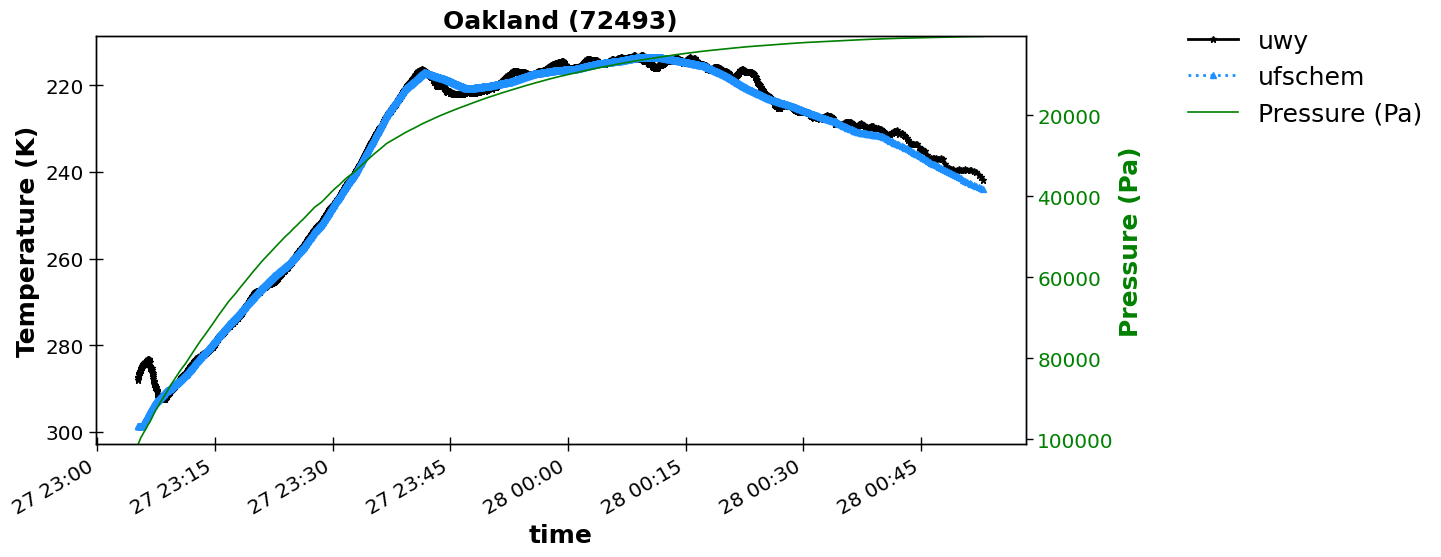

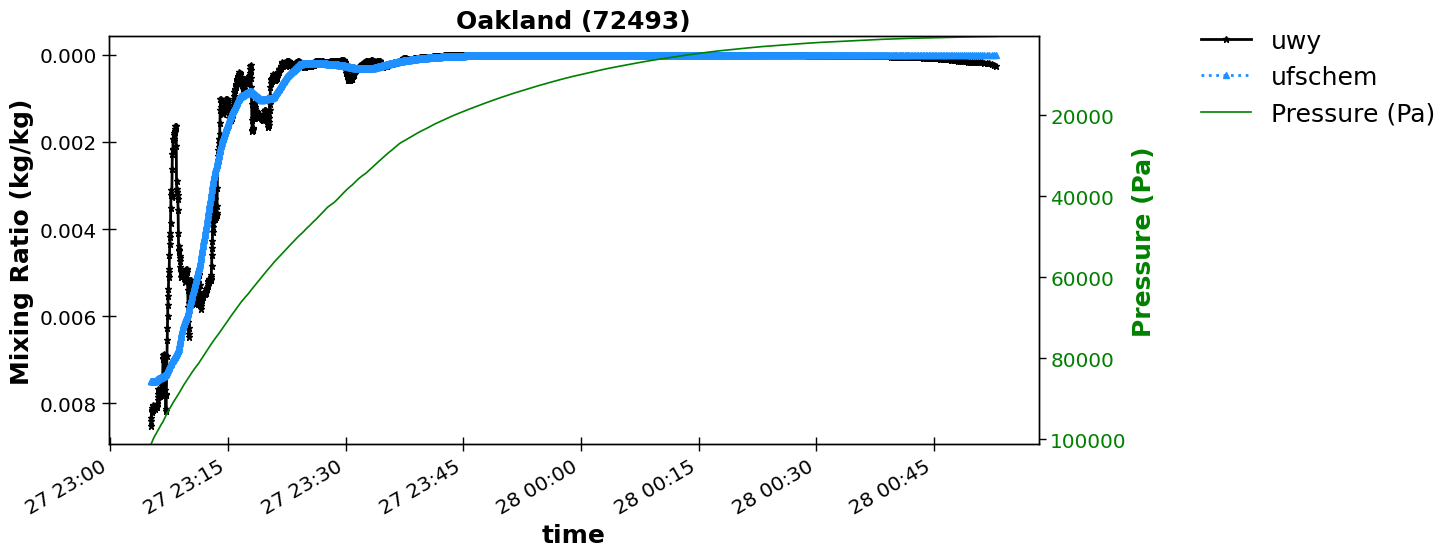

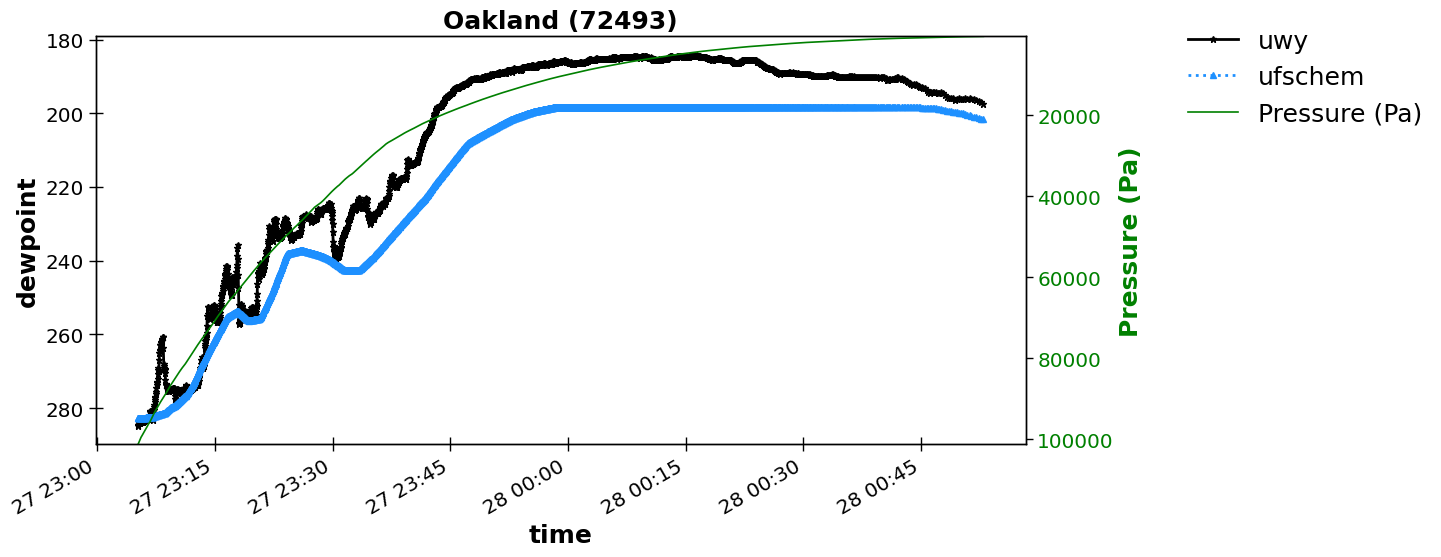

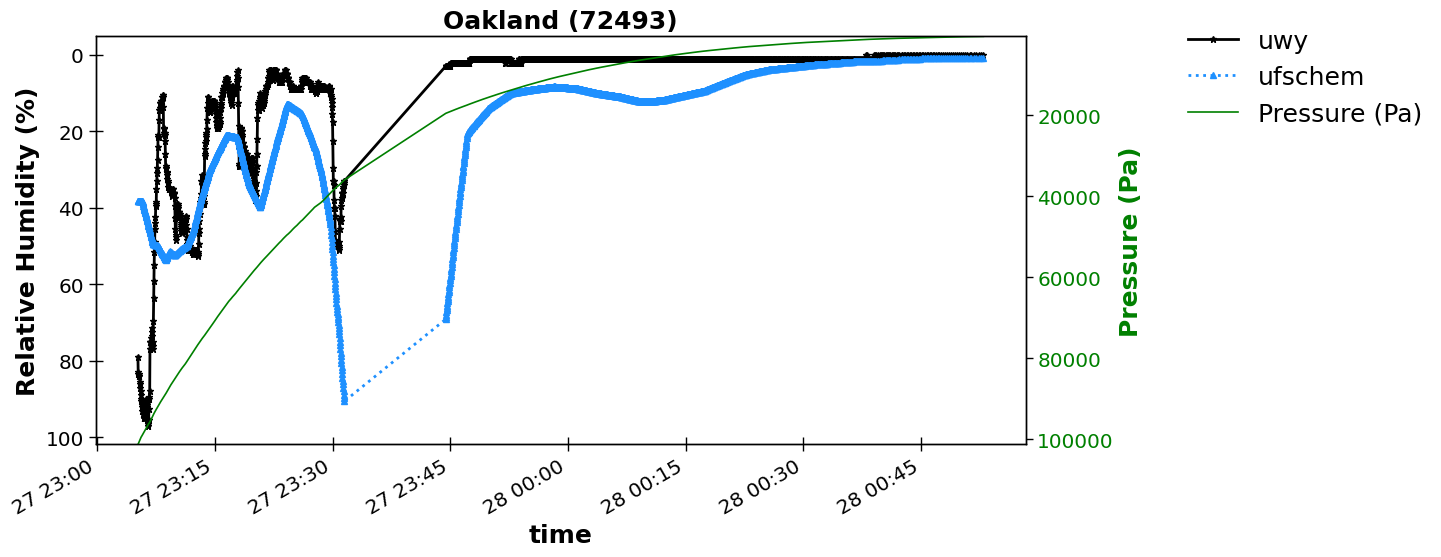

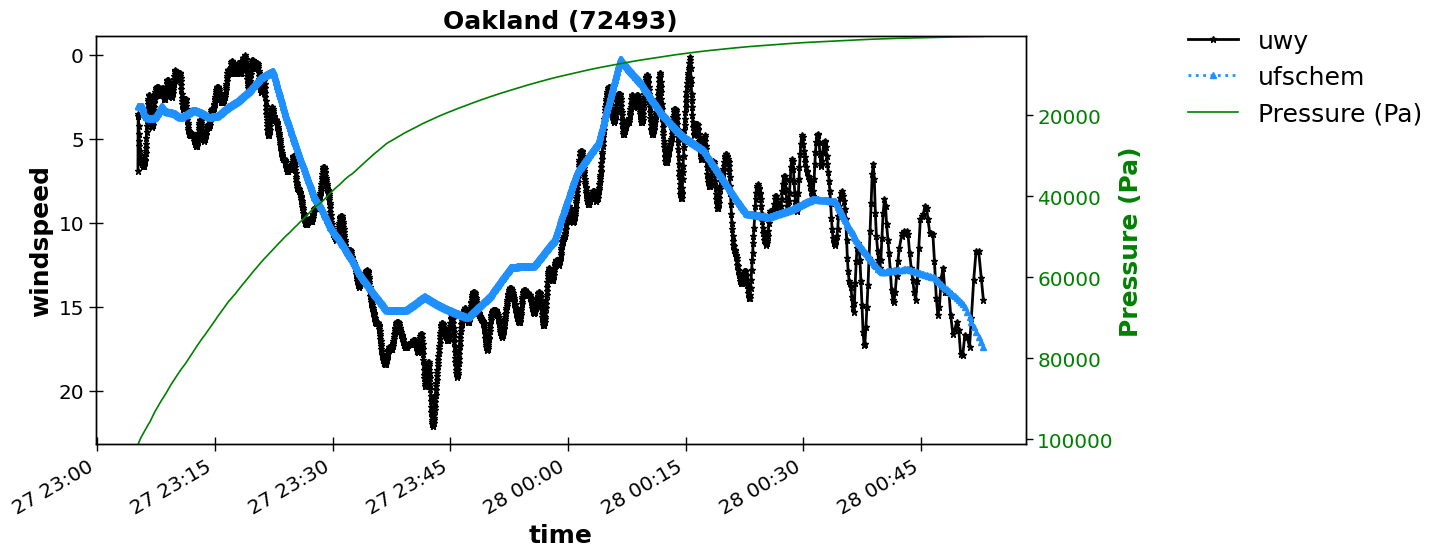

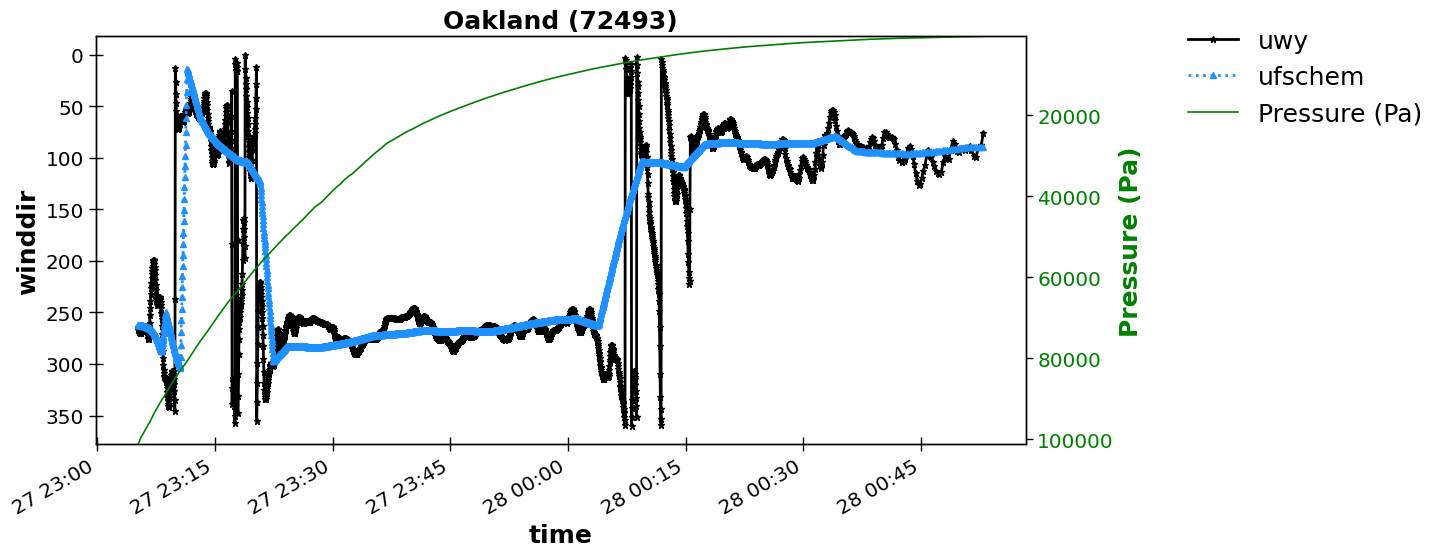

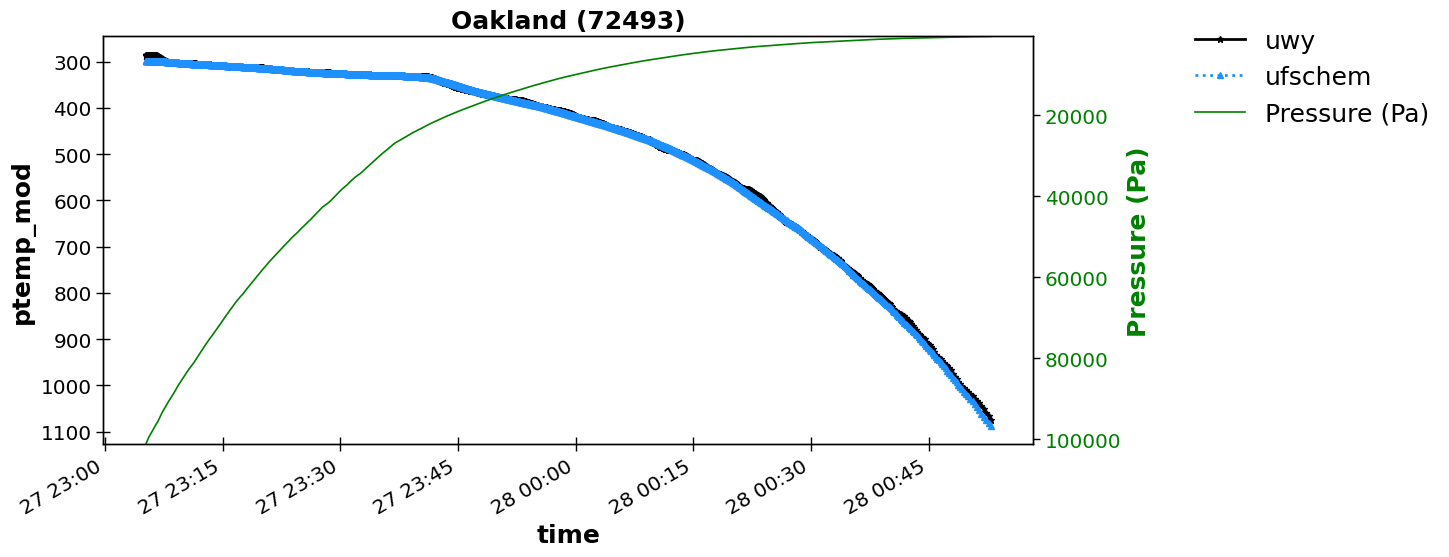

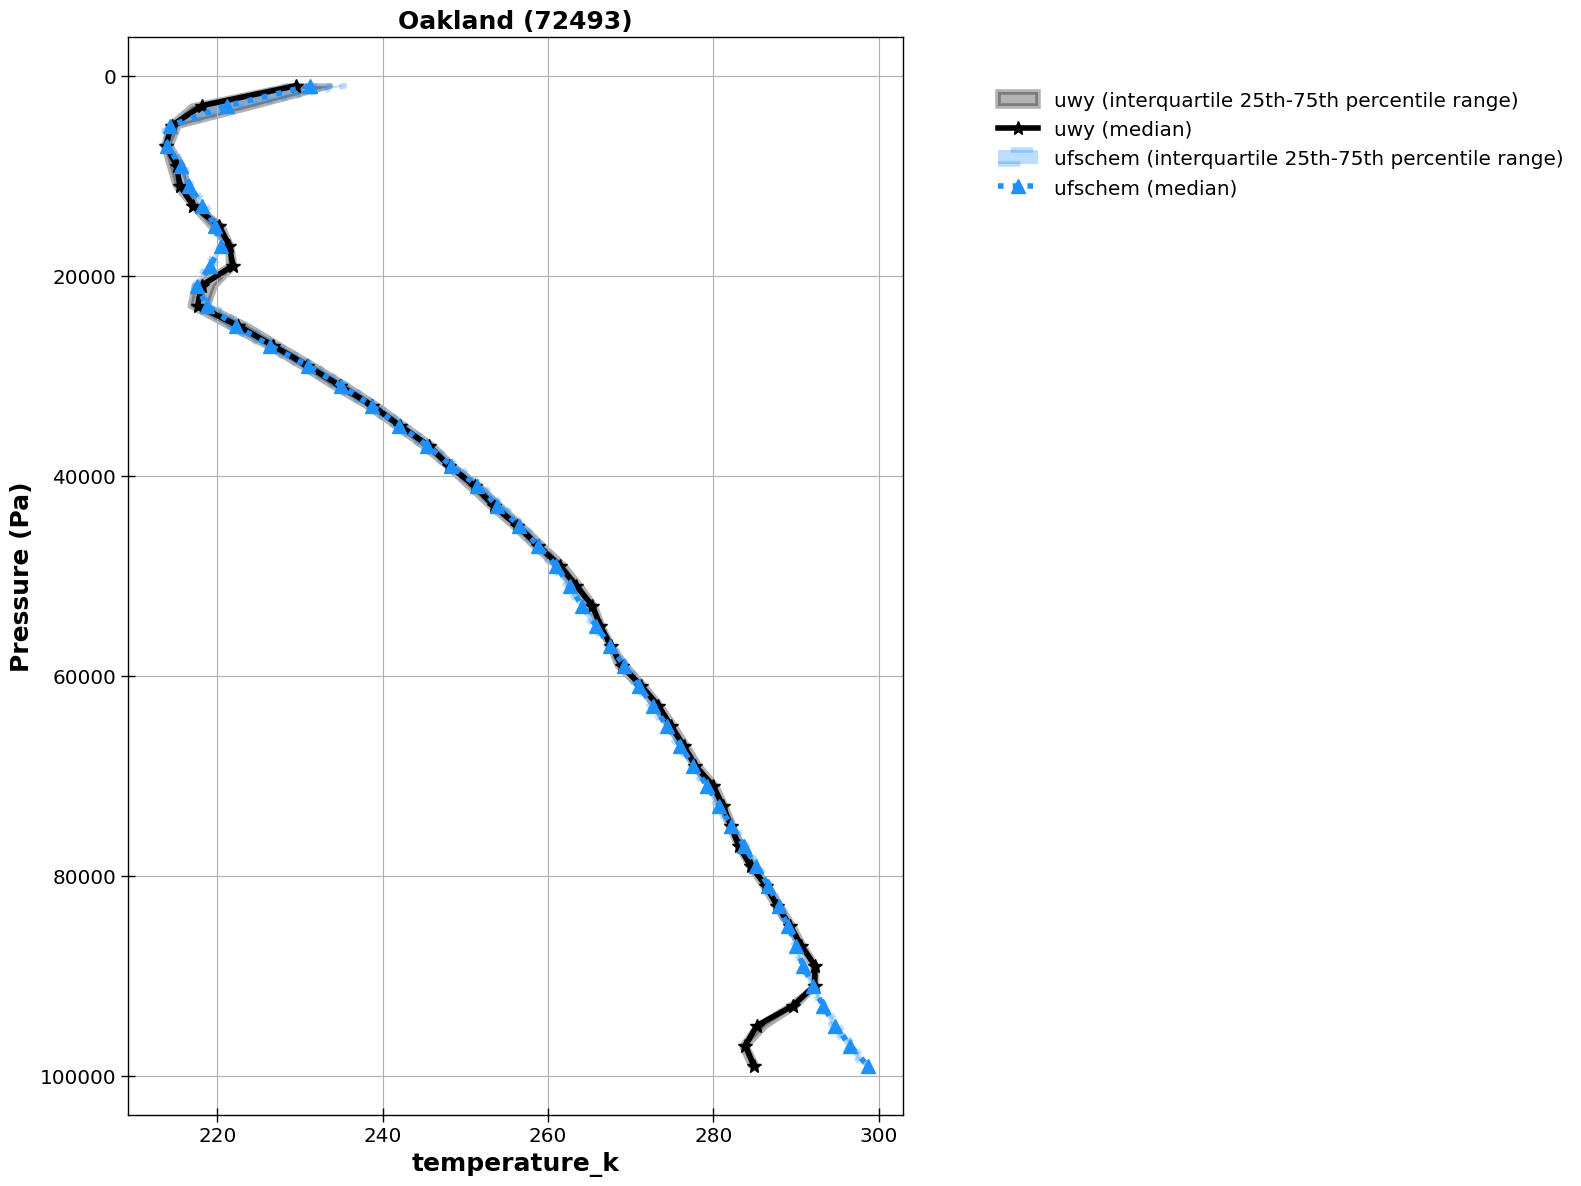

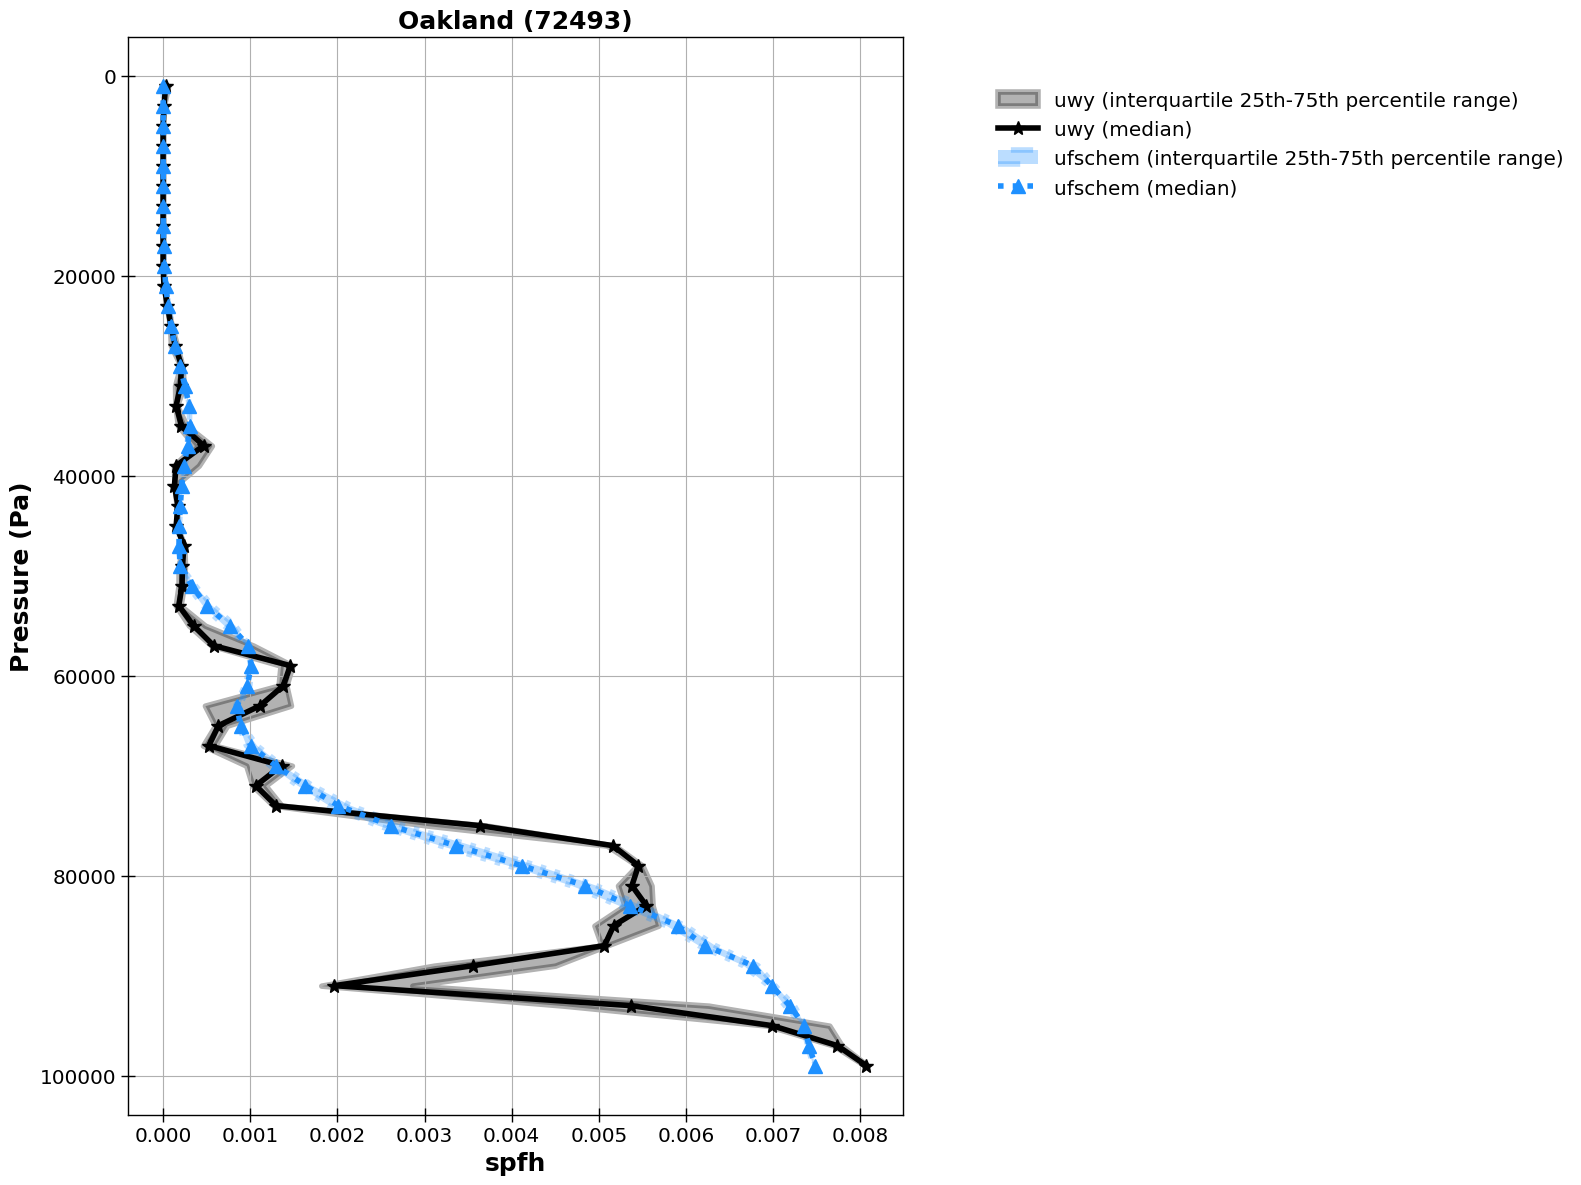

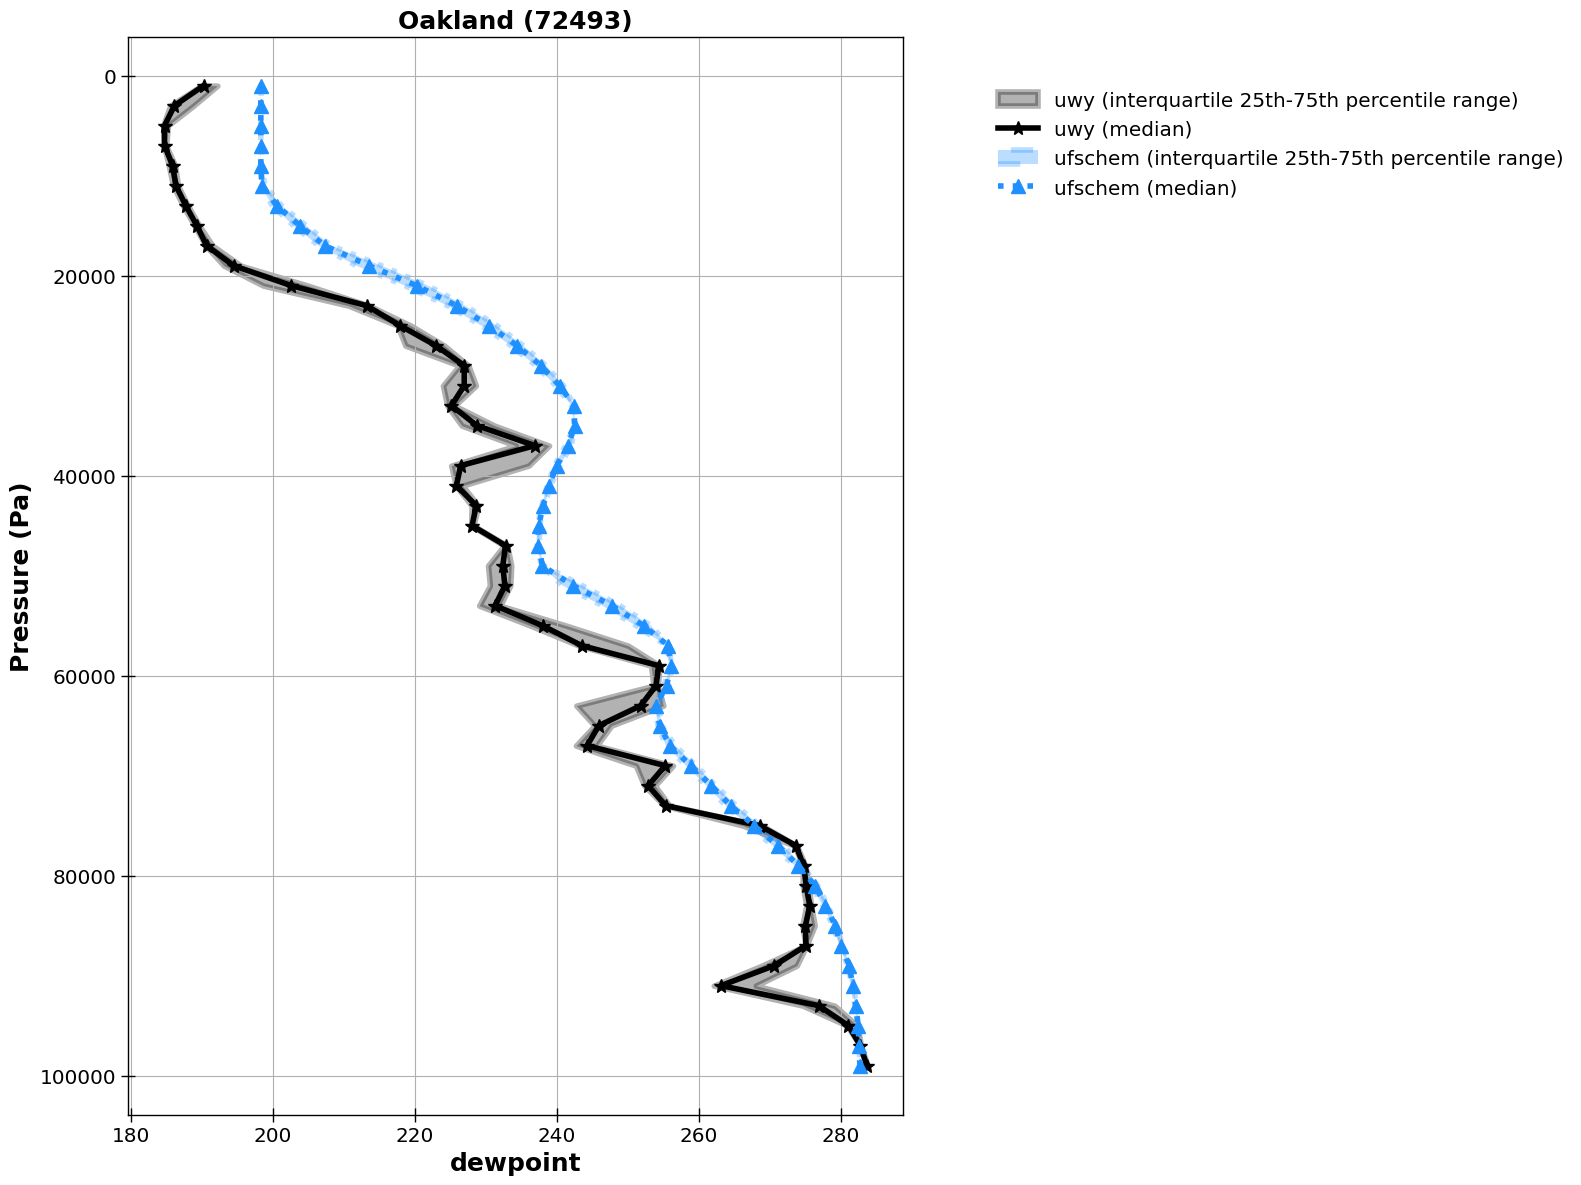

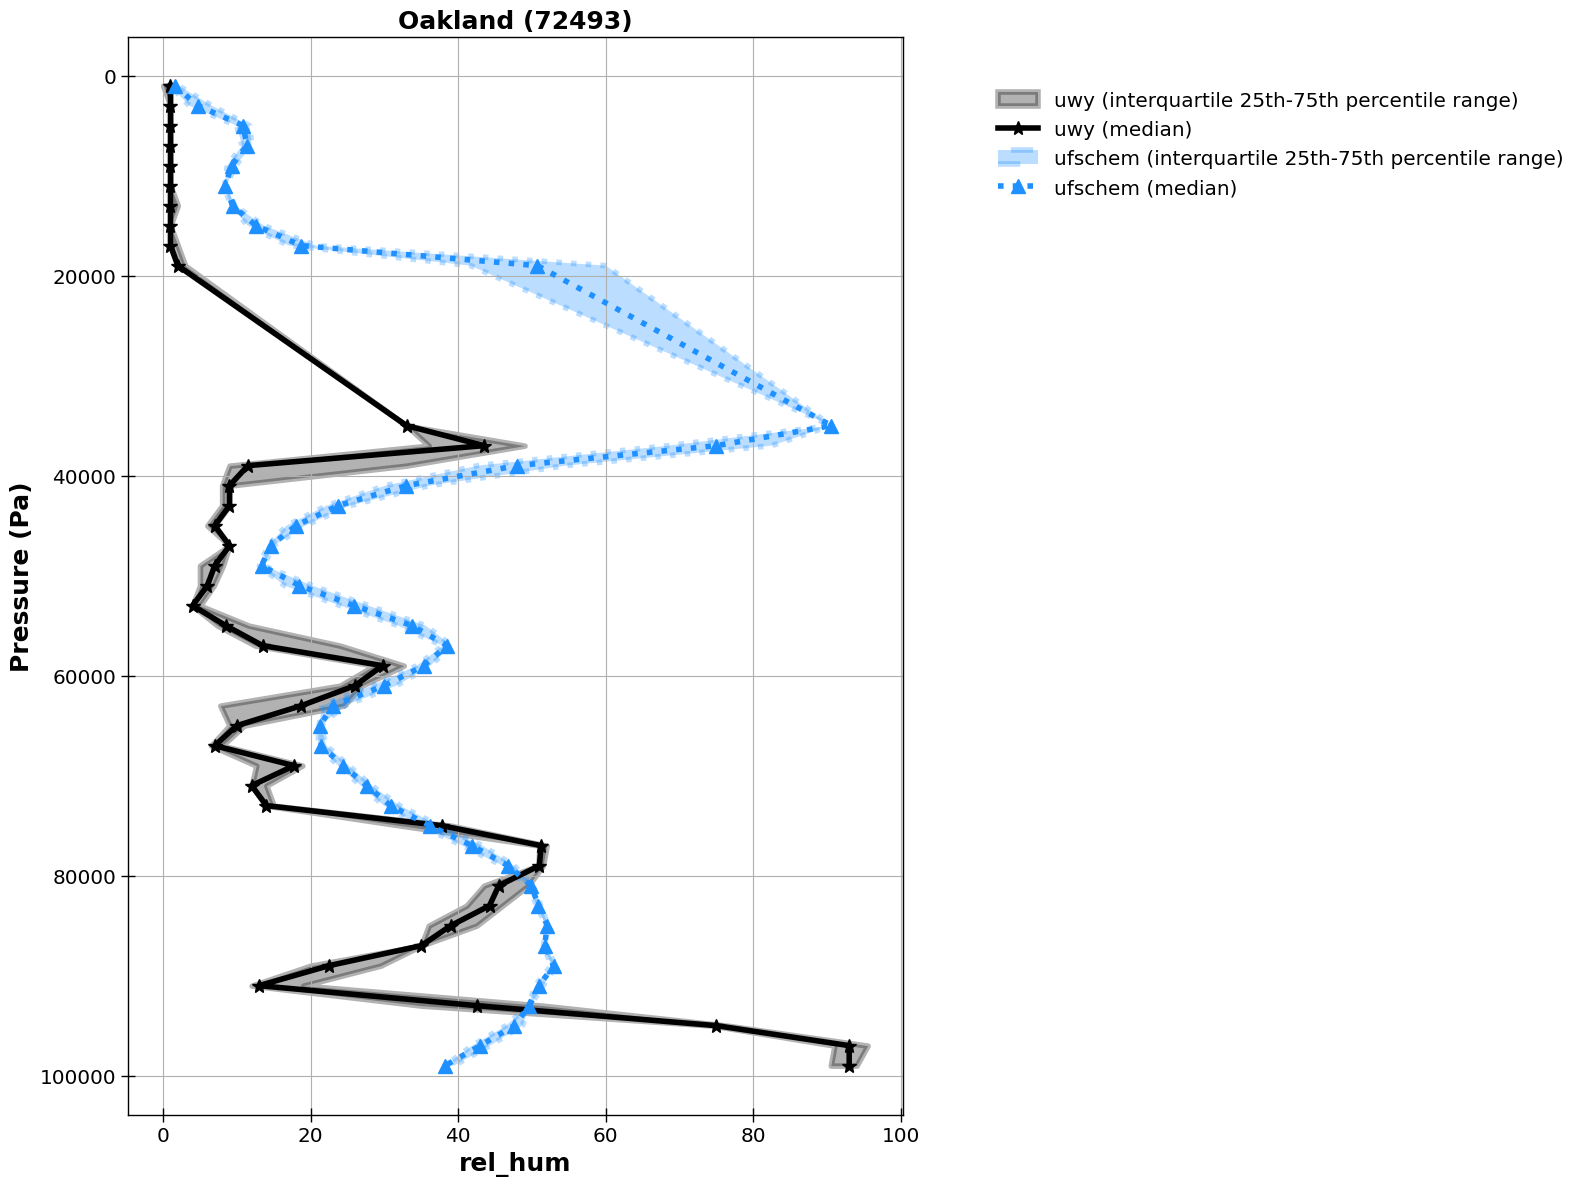

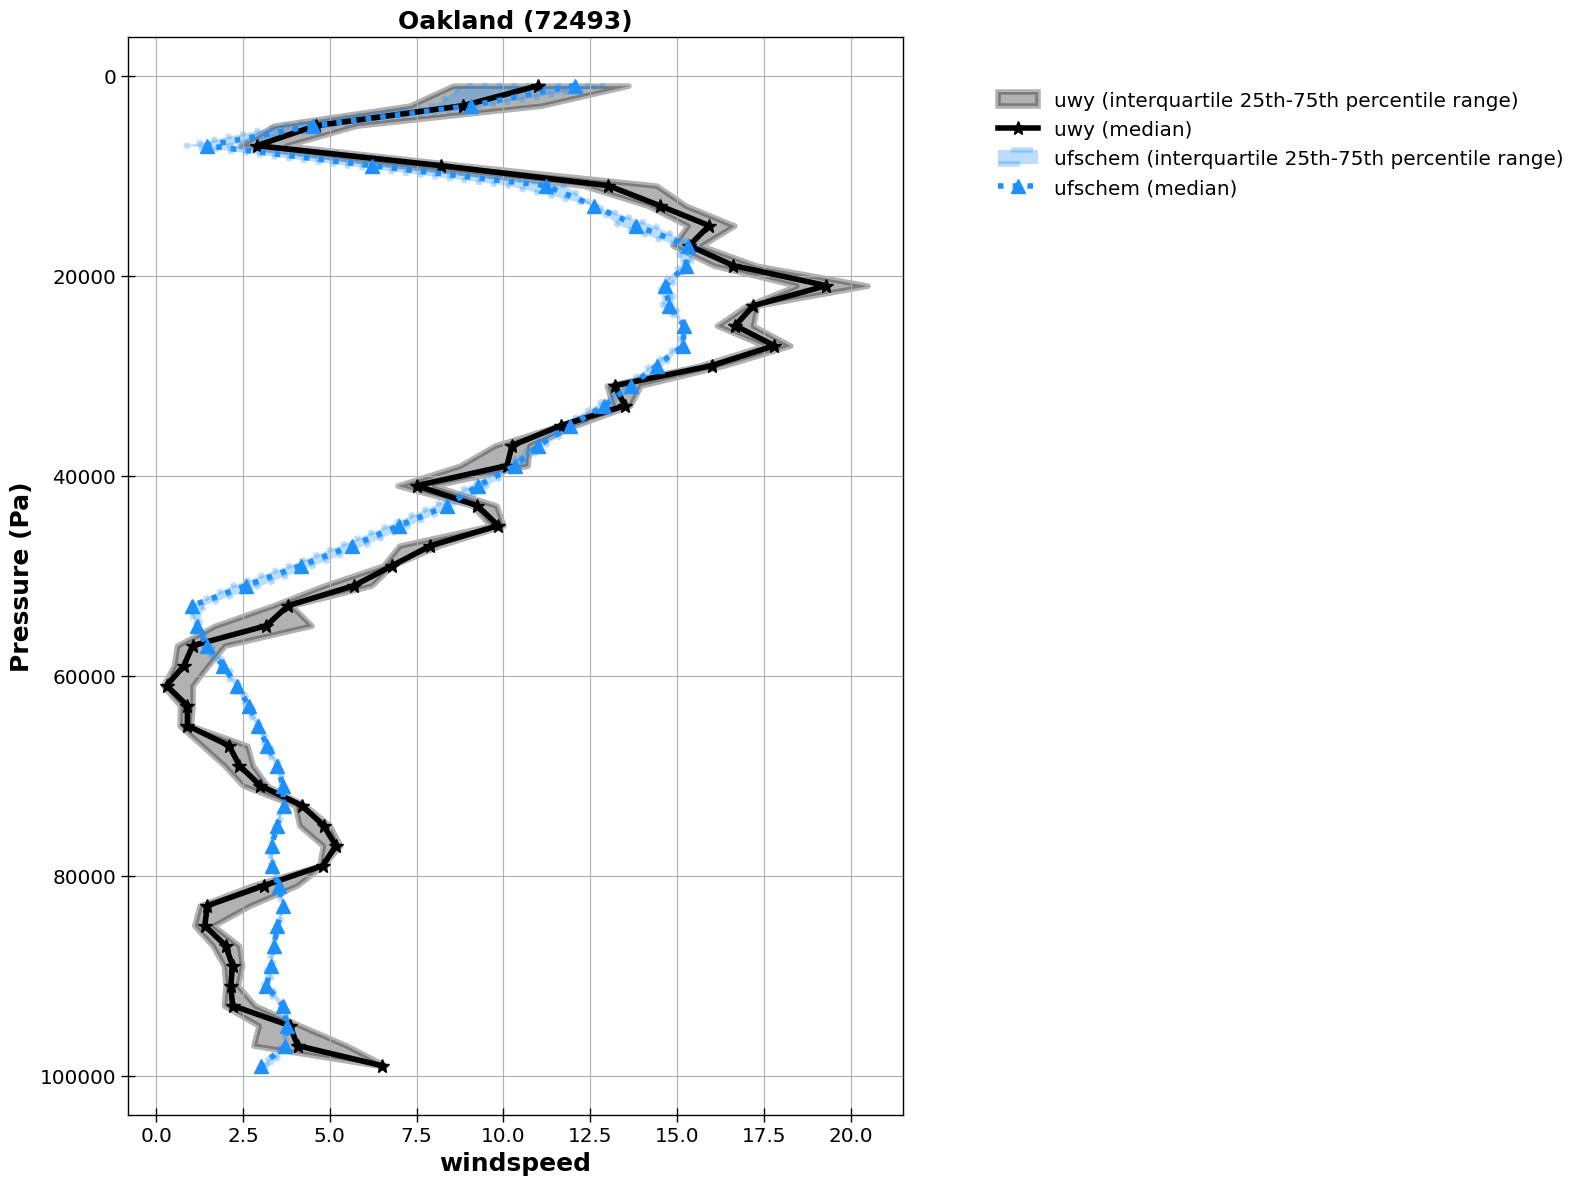

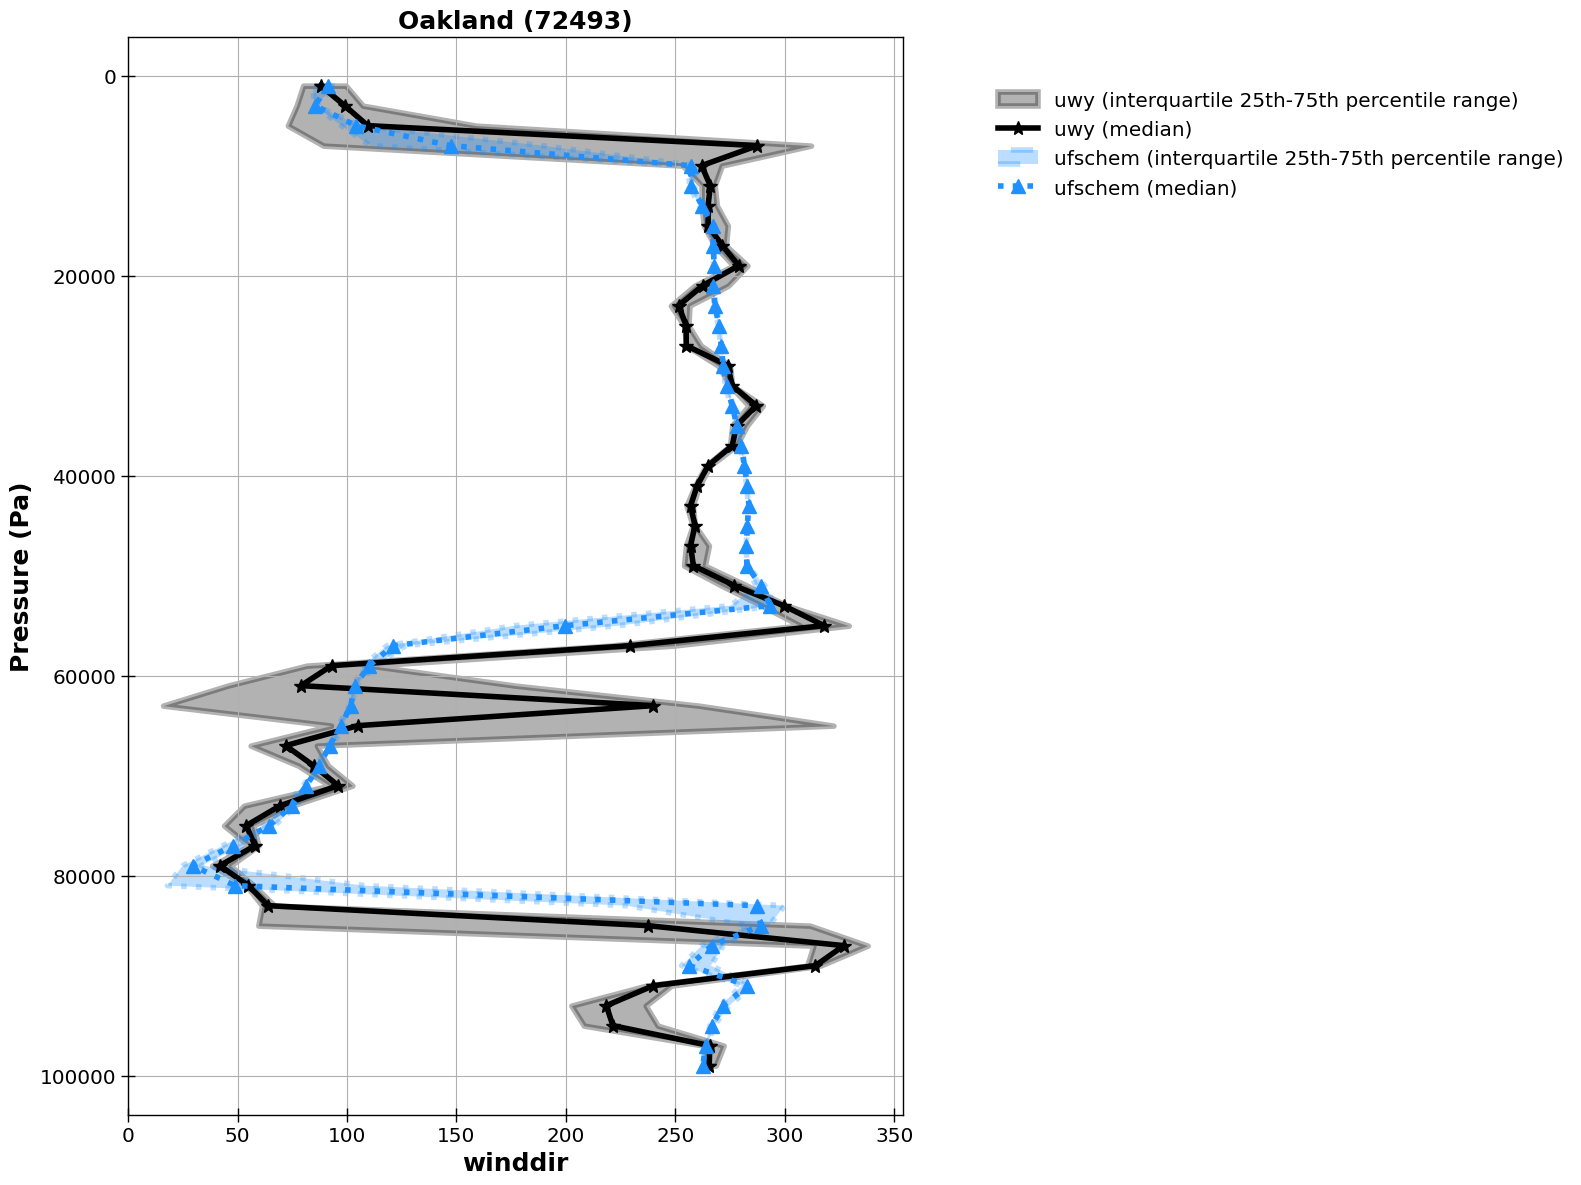

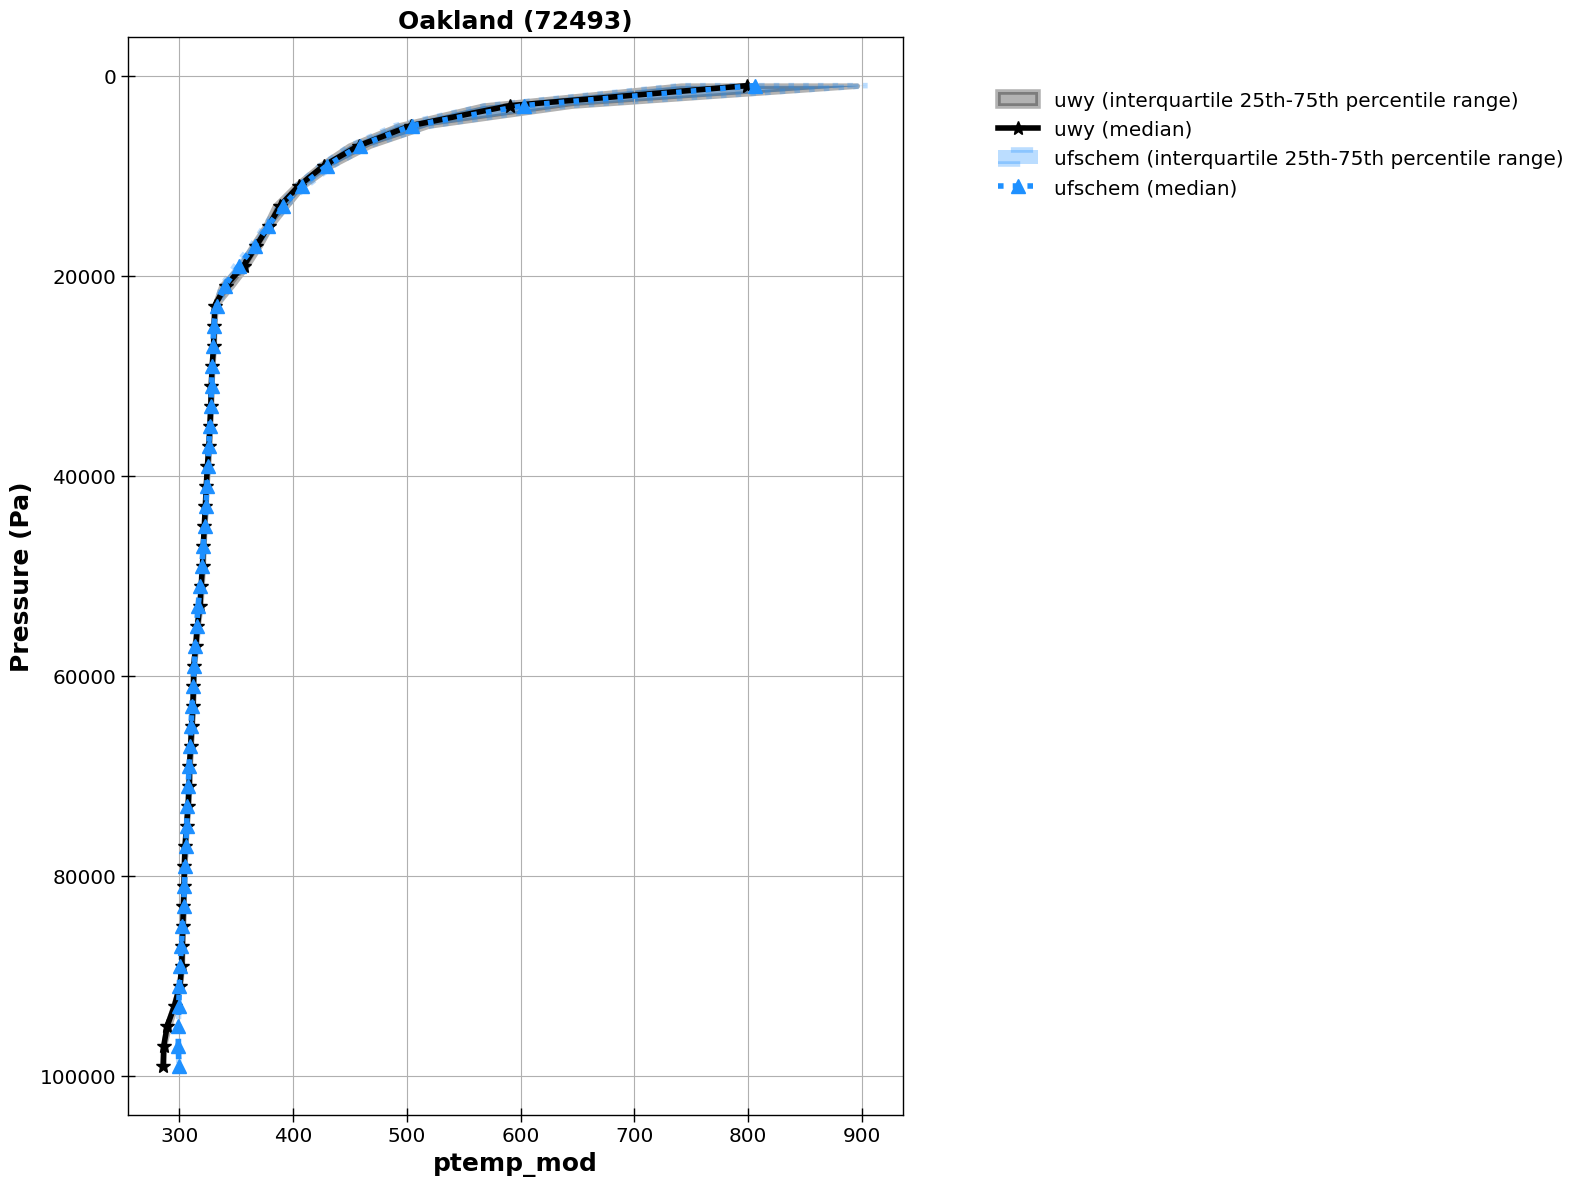

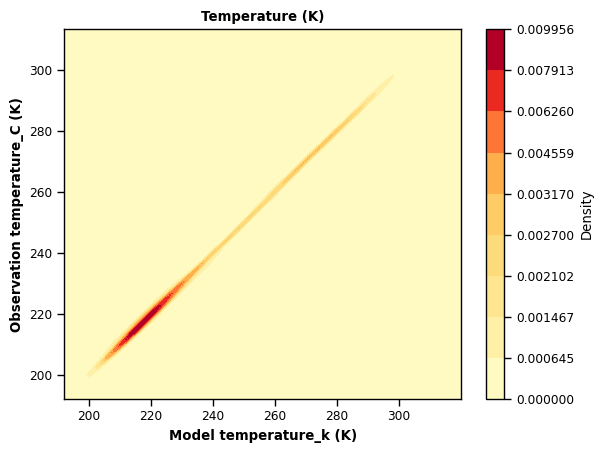

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.w.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...
Processing scatter density plot for model 'ufschem' and observation 'uwy'...
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.w.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...


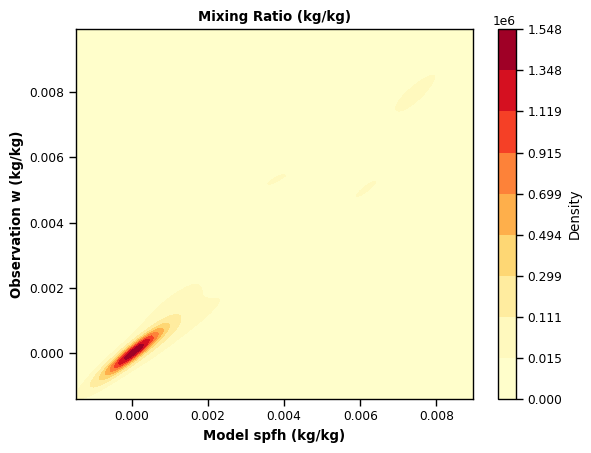

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.dpt_obs.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...
Processing scatter density plot for model 'ufschem' and observation 'uwy'...
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.dpt_obs.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...


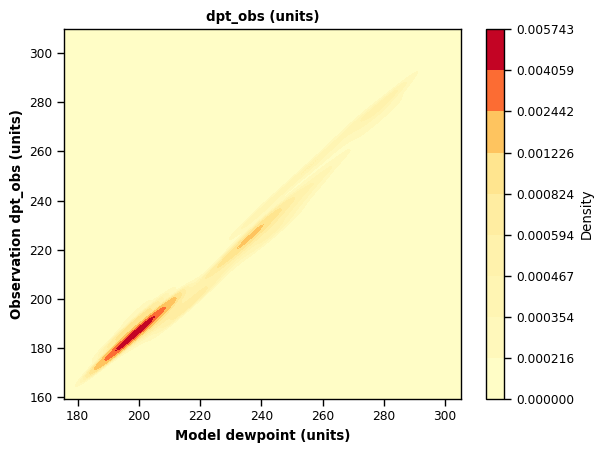

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.relh_obs.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...
Processing scatter density plot for model 'ufschem' and observation 'uwy'...
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.relh_obs.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...


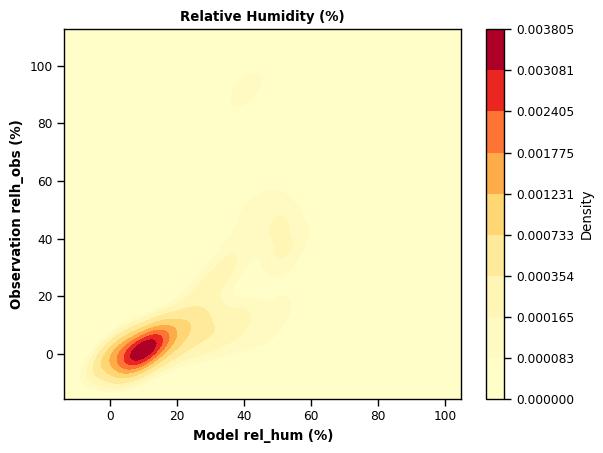

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.windspeed_obs.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...
Processing scatter density plot for model 'ufschem' and observation 'uwy'...
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.windspeed_obs.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...


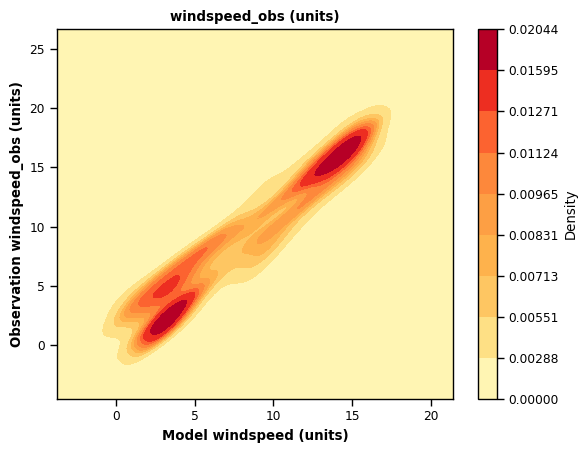

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.wdir_obs.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...
Processing scatter density plot for model 'ufschem' and observation 'uwy'...
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.wdir_obs.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...


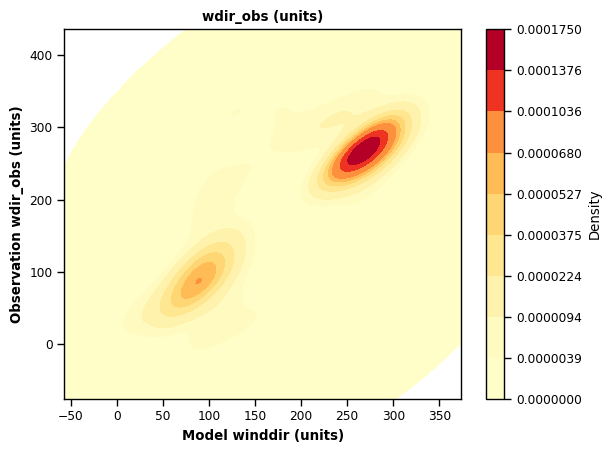

Value of fill after reading from scatter_density_config: True
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.ptemp_obs.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...
Processing scatter density plot for model 'ufschem' and observation 'uwy'...
Saving scatter density plot to ./output/uwy_ufschem/plot_grp3.scatter_density.ptemp_obs.2023-06-27_23.2023-06-28_23.all.Oakland (72493)_uwy_vs_ufschem.png...


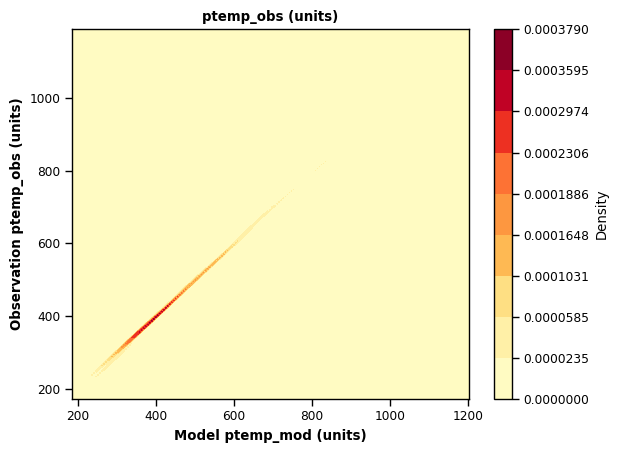

In [14]:
an.plotting()